# PointNet (Fast) — Классификация LAS


## 1. Установка и проверка GPU

In [ ]:
!pip install laspy tqdm -q
import os, json, pickle, time, numpy as np, torch
import torch.nn as nn, torch.nn.functional as F, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import laspy
from pathlib import Path
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("WARNING: no GPU — Runtime -> Change runtime type -> T4 GPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 3.9 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Google Drive и пути к файлам

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

# ===== УКАЖИТЕ ВАШИ ПУТИ =====
LAS_FILES = [
    "/content/drive/MyDrive/files2/cloud1_train.las",
]
CHECKPOINT_DIR = "/content/drive/MyDrive/files2/pointnet_fast_checkpoints1"
# ==============================

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
for f in LAS_FILES:
    status = "OK" if os.path.exists(f) else "NOT FOUND"
    print(f"{status}: {f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK: /content/drive/MyDrive/files2/cloud1_train.las


## 3. Константы и маппинг классов

In [ ]:
CLASS_MAP     = {2: 0, 4: 1, 14: 2}
CLASS_MAP_INV = {0: 2, 1: 4, 2: 14}
CLASS_NAMES   = {0: "ground", 1: "med_vegetation", 2: "powerlines"}
IGNORE_INDEX  = -1
print("Constants defined OK")

Constants defined OK


## 4. Датасет с кешированием патчей
> Нарезка один раз при старте —  мгновенный

In [ ]:
class FastLASDataset(Dataset):
    def __init__(self, las_files, patch_size=2048, num_patches=800,
                 powerline_oversample=10, is_train=True, val_split=0.15,
                 seed=42, verbose=True):
        super().__init__()
        self.patch_size = patch_size
        self.is_train   = is_train
        rng = np.random.default_rng(seed)
        if isinstance(las_files, str): las_files = [las_files]
        all_pts, all_lbl, norm_params = [], [], None
        for fpath in las_files:
            pts, lbl, norm_params = self._load_file(fpath, verbose)
            all_pts.append(pts); all_lbl.append(lbl)
        points = np.concatenate(all_pts)
        labels = np.concatenate(all_lbl)
        self.norm_params = norm_params
        N = len(points)
        if verbose: print(f"Total points: {N:,}")
        known_idx = np.where(labels != IGNORE_INDEX)[0]
        pw_idx    = np.where(labels == 2)[0]
        if verbose: print(f"Powerlines: {len(pw_idx):,} pts, oversample x{powerline_oversample}")
        base = rng.choice(known_idx, size=num_patches, replace=True)
        if len(pw_idx) > 0 and powerline_oversample > 1:
            extra = rng.choice(pw_idx, size=num_patches*(powerline_oversample-1), replace=True)
            centers = np.concatenate([base, extra])
        else:
            centers = base
        rng.shuffle(centers)
        split = int(len(centers) * (1 - val_split))
        centers = centers[:split] if is_train else centers[split:]
        mode = "train" if is_train else "val"
        if verbose: print(f"Pre-cutting {len(centers)} patches [{mode}]...")
        t0 = time.time()
        xy = points[:, :2]
        self.patches_pts = np.empty((len(centers), patch_size, 6), dtype=np.float32)
        self.patches_lbl = np.empty((len(centers), patch_size),    dtype=np.int64)
        for i, ci in enumerate(centers):
            cx, cy = xy[ci]
            cand_n = min(N, patch_size * 12)
            cand   = rng.choice(N, cand_n, replace=False)
            dx = xy[cand, 0] - cx; dy = xy[cand, 1] - cy
            order = np.argsort(dx*dx + dy*dy)[:patch_size]
            idx = cand[order]
            if len(idx) < patch_size:
                idx = np.concatenate([idx, rng.choice(idx, patch_size-len(idx), replace=True)])
            p = points[idx].copy()
            p[:, 0] -= p[:, 0].mean(); p[:, 1] -= p[:, 1].mean()
            self.patches_pts[i] = p
            self.patches_lbl[i] = labels[idx]
        ram_mb = (self.patches_pts.nbytes + self.patches_lbl.nbytes) / 1e6
        if verbose:
            print(f"Done in {time.time()-t0:.1f}s | RAM: {ram_mb:.0f} MB [{mode}]")
            flat = self.patches_lbl.flatten()
            known = flat[flat != IGNORE_INDEX]
            for c, cnt in zip(*np.unique(known, return_counts=True)):
                print(f"  {CLASS_NAMES.get(c,str(c))}: {cnt/len(known)*100:.1f}%")

    @staticmethod
    def _load_file(fpath, verbose):
        las = laspy.read(fpath)
        n   = las.header.point_count
        if verbose: print(f"Loading {Path(fpath).name}: {n:,} points")
        x   = np.array(las.x, dtype=np.float32)
        y   = np.array(las.y, dtype=np.float32)
        z   = np.array(las.z, dtype=np.float32)
        cls = np.array(las.classification, dtype=np.int32)
        dims = las.point_format.dimension_names
        intensity = np.array(las.intensity,         dtype=np.float32) if "intensity"         in dims else np.zeros(n, np.float32)
        ret_num   = np.array(las.return_number,     dtype=np.float32) if "return_number"     in dims else np.ones(n,  np.float32)
        ret_total = np.array(las.number_of_returns, dtype=np.float32) if "number_of_returns" in dims else np.ones(n,  np.float32)
        x_n = (x-x.min())/(x.max()-x.min()+1e-8)
        y_n = (y-y.min())/(y.max()-y.min()+1e-8)
        z_n = (z-z.min())/(z.max()-z.min()+1e-8)
        i_n = intensity/(intensity.max()+1e-8)
        r_n = ret_num/(ret_total+1e-8)
        points = np.stack([x_n,y_n,z_n,z_n,i_n,r_n], axis=1)
        labels = np.full(n, IGNORE_INDEX, dtype=np.int64)
        for lc, idx in CLASS_MAP.items(): labels[cls==lc] = idx
        if verbose:
            known = labels != IGNORE_INDEX
            print(f"  Known: {known.sum():,} ({known.mean()*100:.1f}%)")
            for c, cnt in zip(*np.unique(labels[known], return_counts=True)):
                print(f"    [{CLASS_NAMES.get(c,str(c))}]: {cnt:,} ({cnt/n*100:.2f}%)")
        norm_params = {"x_min":float(x.min()),"x_max":float(x.max()),
                       "y_min":float(y.min()),"y_max":float(y.max()),
                       "z_min":float(z.min()),"z_max":float(z.max())}
        return points, labels, norm_params

    def __len__(self): return len(self.patches_pts)

    def __getitem__(self, i):
        pts = self.patches_pts[i].copy()
        lbl = self.patches_lbl[i].copy()
        if self.is_train:
            a = np.random.uniform(0, 2*np.pi)
            c, s = np.cos(a), np.sin(a)
            pts[:, :2] = pts[:, :2] @ np.array([[c,-s],[s,c]], dtype=np.float32).T
            pts[:, :3] *= np.random.uniform(0.9, 1.1)
            pts[:, :3] += np.random.normal(0, 0.001, pts[:, :3].shape).astype(np.float32)
            if np.random.random() < 0.5: pts[:, 0] *= -1
        return torch.from_numpy(pts), torch.from_numpy(lbl)

print("FastLASDataset defined OK")

FastLASDataset defined OK


## 5. Модель PointNet (feature TNet сохранён)

In [ ]:
class TNet(nn.Module):
    def __init__(self, k=64):
        super().__init__()
        self.k = k
        self.conv1=nn.Conv1d(k,64,1); self.conv2=nn.Conv1d(64,128,1); self.conv3=nn.Conv1d(128,1024,1)
        self.fc1=nn.Linear(1024,512); self.fc2=nn.Linear(512,256); self.fc3=nn.Linear(256,k*k)
        self.bn1=nn.BatchNorm1d(64); self.bn2=nn.BatchNorm1d(128); self.bn3=nn.BatchNorm1d(1024)
        self.bn4=nn.BatchNorm1d(512); self.bn5=nn.BatchNorm1d(256)
    def forward(self, x):
        B=x.size(0)
        x=F.relu(self.bn1(self.conv1(x))); x=F.relu(self.bn2(self.conv2(x))); x=F.relu(self.bn3(self.conv3(x)))
        x=x.max(dim=2).values
        x=F.relu(self.bn4(self.fc1(x))); x=F.relu(self.bn5(self.fc2(x))); x=self.fc3(x)
        eye=torch.eye(self.k,device=x.device).flatten().unsqueeze(0).expand(B,-1)
        return (x+eye).view(B,self.k,self.k)

class PointNetSeg(nn.Module):
    def __init__(self, num_classes=3, in_features=6, dropout=0.3):
        super().__init__()
        self.conv1=nn.Conv1d(in_features,64,1); self.conv2=nn.Conv1d(64,64,1)
        self.tnet=TNet(k=64)
        self.conv3=nn.Conv1d(64,64,1); self.conv4=nn.Conv1d(64,128,1); self.conv5=nn.Conv1d(128,1024,1)
        self.bn1=nn.BatchNorm1d(64); self.bn2=nn.BatchNorm1d(64); self.bn3=nn.BatchNorm1d(64)
        self.bn4=nn.BatchNorm1d(128); self.bn5=nn.BatchNorm1d(1024)
        self.seg1=nn.Conv1d(1088,512,1); self.seg2=nn.Conv1d(512,256,1)
        self.seg3=nn.Conv1d(256,128,1); self.seg4=nn.Conv1d(128,num_classes,1)
        self.sbn1=nn.BatchNorm1d(512); self.sbn2=nn.BatchNorm1d(256); self.sbn3=nn.BatchNorm1d(128)
        self.drop=nn.Dropout(p=dropout)
    def forward(self, x):
        B,N,_=x.shape; x=x.transpose(2,1)
        x=F.relu(self.bn1(self.conv1(x))); x=F.relu(self.bn2(self.conv2(x)))
        local_feat=x
        x=torch.bmm(self.tnet(x),x)
        x=F.relu(self.bn3(self.conv3(x))); x=F.relu(self.bn4(self.conv4(x))); x=F.relu(self.bn5(self.conv5(x)))
        gf=x.max(dim=2).values.unsqueeze(2).expand(-1,-1,N)
        x=torch.cat([local_feat,gf],dim=1)
        x=F.relu(self.sbn1(self.seg1(x))); x=self.drop(x)
        x=F.relu(self.sbn2(self.seg2(x))); x=self.drop(x)
        x=F.relu(self.sbn3(self.seg3(x))); x=self.seg4(x)
        return x.transpose(2,1)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.gamma=gamma
        self.alpha=torch.tensor(alpha,dtype=torch.float32) if alpha else None
    def forward(self, inputs, targets):
        alpha=self.alpha.to(inputs.device) if self.alpha is not None else None
        ce=F.cross_entropy(inputs,targets,weight=alpha,ignore_index=IGNORE_INDEX,reduction="none")
        mask=(targets!=IGNORE_INDEX).float()
        pt=torch.exp(-ce)
        return (((1-pt)**self.gamma)*ce*mask).sum()/mask.sum().clamp(min=1)

x_test=torch.randn(2,512,6)
m_test=PointNetSeg()
y_test=m_test(x_test)
print(f"Model OK: {list(x_test.shape)} -> {list(y_test.shape)}")
print(f"Parameters: {sum(p.numel() for p in m_test.parameters()):,}")
del x_test,m_test,y_test

Model OK: [2, 512, 6] -> [2, 512, 3]
Parameters: 2,733,187


## 6. Конфигурация
> Здесь можно менять параметры

In [ ]:
CONFIG = {
    "las_files":             LAS_FILES,
    "patch_size":            2048,
    "num_patches":           800,
    "powerline_oversample":  10,
    "val_split":             0.15,
    "in_features":           6,
    "num_classes":           3,
    "dropout":               0.3,
    "class_weights":         [1.0, 1.5, 25.0],
    "focal_gamma":           2.0,
    "epochs":                60,
    "batch_size":            32,
    "lr":                    0.001,
    "lr_decay":              0.5,
    "lr_step":               30,
    "weight_decay":          1e-4,
    "use_amp":               True,
    "checkpoint_dir":        CHECKPOINT_DIR,
    "save_every":            25,
    "seed":                  42,
}
for k,v in CONFIG.items(): print(f"  {k}: {v}")

  las_files: ['/content/drive/MyDrive/files2/cloud1_train.las']
  patch_size: 2048
  num_patches: 800
  powerline_oversample: 10
  val_split: 0.15
  in_features: 6
  num_classes: 3
  dropout: 0.3
  class_weights: [1.0, 1.5, 25.0]
  focal_gamma: 2.0
  epochs: 60
  batch_size: 32
  lr: 0.001
  lr_decay: 0.5
  lr_step: 30
  weight_decay: 0.0001
  use_amp: True
  checkpoint_dir: /content/drive/MyDrive/files2/pointnet_fast_checkpoints1
  save_every: 25
  seed: 42


## 7. Создание датасетов

In [ ]:
print("Creating datasets (pre-cutting patches — one time)...")
train_ds = FastLASDataset(
    las_files=CONFIG["las_files"],
    patch_size=CONFIG["patch_size"],
    num_patches=CONFIG["num_patches"],
    powerline_oversample=CONFIG["powerline_oversample"],
    is_train=True, val_split=CONFIG["val_split"], seed=CONFIG["seed"],
)
val_ds = FastLASDataset(
    las_files=CONFIG["las_files"],
    patch_size=CONFIG["patch_size"],
    num_patches=max(100, CONFIG["num_patches"]//4),
    powerline_oversample=CONFIG["powerline_oversample"],
    is_train=False, val_split=CONFIG["val_split"], seed=CONFIG["seed"], verbose=True,
)
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
    shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["batch_size"],
    shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
with open(os.path.join(CONFIG["checkpoint_dir"],"norm_params.pkl"),"wb") as f:
    pickle.dump(train_ds.norm_params, f)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Creating datasets (pre-cutting patches — one time)...
Loading cloud1_train.las: 4,480,284 points
  Known: 4,480,284 (100.0%)
    [ground]: 527,320 (11.77%)
    [med_vegetation]: 3,941,436 (87.97%)
    [powerlines]: 11,528 (0.26%)
Total points: 4,480,284
Powerlines: 11,528 pts, oversample x10
Pre-cutting 6800 patches [train]...
Done in 17.5s | RAM: 446 MB [train]
  ground: 14.0%
  med_vegetation: 85.5%
  powerlines: 0.5%
Loading cloud1_train.las: 4,480,284 points
  Known: 4,480,284 (100.0%)
    [ground]: 527,320 (11.77%)
    [med_vegetation]: 3,941,436 (87.97%)
    [powerlines]: 11,528 (0.26%)
Total points: 4,480,284
Powerlines: 11,528 pts, oversample x10
Pre-cutting 300 patches [val]...
Done in 0.7s | RAM: 20 MB [val]
  ground: 13.8%
  med_vegetation: 85.7%
  powerlines: 0.5%
Train batches: 212 | Val batches: 10


## 8. Инициализация модели

In [ ]:
torch.manual_seed(CONFIG["seed"]); np.random.seed(CONFIG["seed"])
model     = PointNetSeg(num_classes=CONFIG["num_classes"],
                        in_features=CONFIG["in_features"],
                        dropout=CONFIG["dropout"]).to(device)
criterion = FocalLoss(alpha=CONFIG["class_weights"], gamma=CONFIG["focal_gamma"])
optimizer = optim.Adam(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=CONFIG["lr_step"], gamma=CONFIG["lr_decay"])
scaler    = GradScaler(enabled=CONFIG["use_amp"])
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Device: {next(model.parameters()).device}")
# Продолжить с чекпоинта:
ck=torch.load(os.path.join(CHECKPOINT_DIR,"best_powerlines.pt"),map_location=device)
model.load_state_dict(ck["model_state"]); optimizer.load_state_dict(ck["opt_state"])


Parameters: 2,733,187
Device: cuda:0


## 9. Обучение
> Каждая эпоха должна занимать 30-90 секунд на T4 GPU

In [ ]:
def compute_metrics(C):
    n = C.shape[0]
    iou, acc = [], []
    for i in range(n):
        tp = C[i, i]
        iou.append(float(tp / max(C[i].sum() + C[:, i].sum() - tp, 1)))
        acc.append(float(tp / max(C[i].sum(), 1)))
    miou = float(np.mean(iou))
    oa   = float(np.diag(C).sum() / max(C.sum(), 1))
    return miou, iou, acc, oa


def run_epoch(model, loader, criterion, optimizer, scaler, is_train):
    model.train() if is_train else model.eval()
    conf = np.zeros((CONFIG["num_classes"], CONFIG["num_classes"]), dtype=np.int64)
    total_loss, nb = 0.0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for pts, lbl in loader:
            pts = pts.to(device, non_blocking=True)
            lbl = lbl.to(device, non_blocking=True)
            with autocast(device_type=device.type, enabled=CONFIG["use_amp"]):
                logits = model(pts)
                B, N, num_cls = logits.shape
                loss = criterion(logits.reshape(-1, num_cls), lbl.reshape(-1))
            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            preds = logits.argmax(dim=-1).cpu().numpy().flatten()
            true  = lbl.cpu().numpy().flatten()
            mask  = true != IGNORE_INDEX
            for p, t in zip(preds[mask], true[mask]):
                conf[t, p] += 1
            total_loss += loss.item()
            nb += 1
    miou, iou_l, acc_l, oa = compute_metrics(conf)
    return {"loss": total_loss / max(nb, 1), "miou": miou,
            "iou": iou_l, "acc": acc_l, "oa": oa}


def print_metrics(prefix, m):
    epochs_key  = CONFIG["epochs"]
    loss_val    = m["loss"]
    miou_val    = m["miou"] * 100
    oa_val      = m["oa"] * 100
    print(f"  {prefix}  loss={loss_val:.4f}  mIoU={miou_val:.2f}%  OA={oa_val:.2f}%")
    for i in range(CONFIG["num_classes"]):
        iou_i = m["iou"][i] * 100
        acc_i = m["acc"][i] * 100
        name  = CLASS_NAMES[i]
        mark  = " <-- POWERLINES" if i == 2 else ""
        print(f"    {name:18s}: IoU={iou_i:.1f}%  Acc={acc_i:.1f}%{mark}")


# ── Цикл обучения ──────────────────────────────────────────────────────────
log_data    = []
best_miou   = 0.0
best_pw_iou = 0.0
best_epoch  = 0
epoch_times = []

total_epochs = CONFIG["epochs"]
print(f"Training {total_epochs} epochs...")
print("=" * 65)

for epoch in range(1, total_epochs + 1):
    t0 = time.time()
    lr = scheduler.get_last_lr()[0]

    train_m = run_epoch(model, train_loader, criterion, optimizer, scaler, is_train=True)
    val_m   = run_epoch(model, val_loader,   criterion, None,      scaler, is_train=False)
    scheduler.step()

    ep_t = time.time() - t0
    epoch_times.append(ep_t)
    avg_t = np.mean(epoch_times[-5:])
    rem   = avg_t * (total_epochs - epoch) / 60

    print(f"\nEpoch {epoch}/{total_epochs}  lr={lr:.6f}  [{ep_t:.0f}s | ~{rem:.0f} min left]")
    print_metrics("TRAIN", train_m)
    print_metrics("VAL  ", val_m)

    val_miou = val_m["miou"]
    pw_iou   = val_m["iou"][2]

    # Лучший общий mIoU
    if val_miou > best_miou:
        best_miou  = val_miou
        best_epoch = epoch
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "opt_state": optimizer.state_dict(),
            "val_miou": val_miou, "pw_iou": pw_iou, "config": CONFIG,
        }, os.path.join(CONFIG["checkpoint_dir"], "best_model.pt"))
        print(f"  BEST mIoU: {val_miou*100:.2f}% -> best_model.pt")

    # Лучший IoU для проводов (отдельный файл!)
    if pw_iou > best_pw_iou:
        best_pw_iou = pw_iou
        torch.save({
            "epoch": epoch, "model_state": model.state_dict(),
            "opt_state": optimizer.state_dict(),
            "val_miou": val_miou, "pw_iou": pw_iou, "config": CONFIG,
        }, os.path.join(CONFIG["checkpoint_dir"], "best_powerlines.pt"))
        print(f"  BEST powerline IoU: {pw_iou*100:.2f}% -> best_powerlines.pt")

    # Периодическое сохранение
    save_every = CONFIG["save_every"]
    if epoch % save_every == 0 or epoch == total_epochs:
        ck = {
            "epoch": epoch, "model_state": model.state_dict(),
            "opt_state": optimizer.state_dict(),
            "val_miou": val_miou, "pw_iou": pw_iou, "config": CONFIG,
        }
        torch.save(ck, os.path.join(CONFIG["checkpoint_dir"], f"ckpt_epoch{epoch:04d}.pt"))
        torch.save(ck, os.path.join(CONFIG["checkpoint_dir"], "last_model.pt"))

    log_data.append({
        "epoch": epoch, "train": train_m, "val": val_m,
        "lr": lr, "ep_time": ep_t,
    })

# Сохраняем лог
with open(os.path.join(CONFIG["checkpoint_dir"], "train_log.json"), "w") as f:
    json.dump(log_data, f, indent=2)

print("=" * 65)
print(f"Done! Best mIoU: {best_miou*100:.2f}% (epoch {best_epoch})")
print(f"Best powerline IoU: {best_pw_iou*100:.2f}%")

Training 60 epochs...

Epoch 1/60  lr=0.001000  [24s | ~24 min left]
  TRAIN  loss=0.0843  mIoU=68.32%  OA=95.95%
    ground            : IoU=79.8%  Acc=85.9%
    med_vegetation    : IoU=95.4%  Acc=97.6%
    powerlines        : IoU=29.8%  Acc=88.1% <-- POWERLINES
  VAL    loss=0.0290  mIoU=79.30%  OA=97.67%
    ground            : IoU=86.6%  Acc=89.3%
    med_vegetation    : IoU=97.3%  Acc=99.0%
    powerlines        : IoU=53.9%  Acc=99.2% <-- POWERLINES
  BEST mIoU: 79.30% -> best_model.pt
  BEST powerline IoU: 53.95% -> best_powerlines.pt

Epoch 2/60  lr=0.000063  [25s | ~24 min left]
  TRAIN  loss=0.0401  mIoU=77.62%  OA=97.41%
    ground            : IoU=85.5%  Acc=89.7%
    med_vegetation    : IoU=97.0%  Acc=98.7%
    powerlines        : IoU=50.3%  Acc=96.4% <-- POWERLINES
  VAL    loss=0.0236  mIoU=85.27%  OA=97.71%
    ground            : IoU=85.0%  Acc=86.3%
    med_vegetation    : IoU=97.4%  Acc=99.5%
    powerlines        : IoU=73.5%  Acc=99.2% <-- POWERLINES
  BEST mIoU: 85.

## 10. Графики обучения

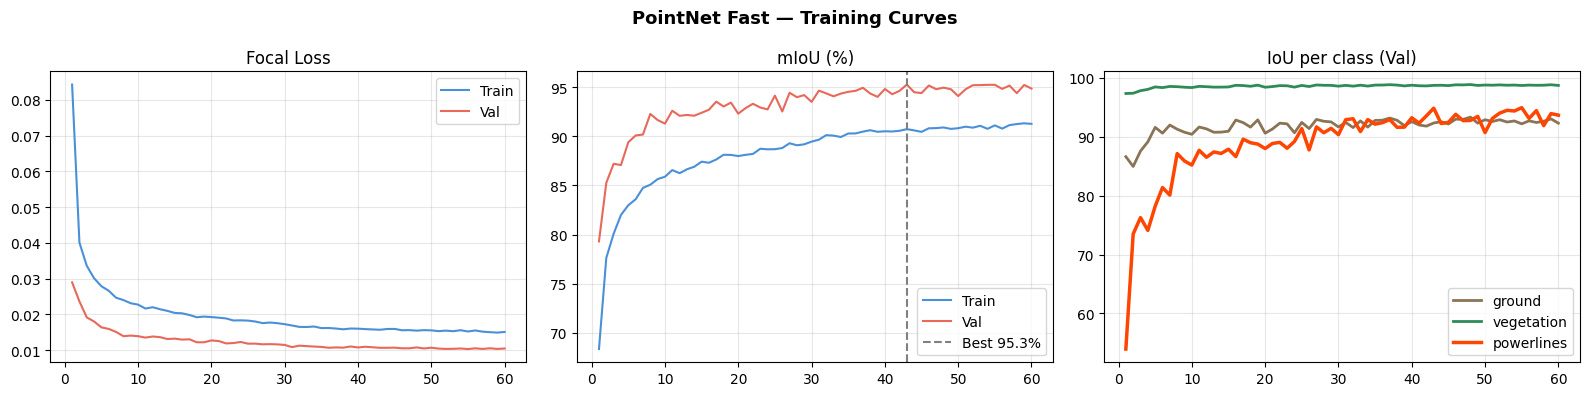

In [ ]:
import matplotlib.pyplot as plt
ep=[e["epoch"] for e in log_data]
fig,axes=plt.subplots(1,3,figsize=(16,4))
fig.suptitle("PointNet Fast — Training Curves",fontsize=13,fontweight="bold")
axes[0].plot(ep,[e["train"]["loss"] for e in log_data],label="Train",color="#4A90D9")
axes[0].plot(ep,[e["val"]["loss"]   for e in log_data],label="Val",  color="#E8685A")
axes[0].set_title("Focal Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
vm=[e["val"]["miou"] for e in log_data]
axes[1].plot(ep,[e["train"]["miou"]*100 for e in log_data],label="Train",color="#4A90D9")
axes[1].plot(ep,[v*100 for v in vm],label="Val",color="#E8685A")
axes[1].axvline(ep[vm.index(max(vm))],color="gray",ls="--",label=f"Best {max(vm)*100:.1f}%")
axes[1].set_title("mIoU (%)"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(ep,[e["val"]["iou"][0]*100 for e in log_data],label="ground",    color="#8B7355",lw=2)
axes[2].plot(ep,[e["val"]["iou"][1]*100 for e in log_data],label="vegetation",color="#2E8B57",lw=2)
axes[2].plot(ep,[e["val"]["iou"][2]*100 for e in log_data],label="powerlines",color="#FF4500",lw=2.5)
axes[2].set_title("IoU per class (Val)"); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["checkpoint_dir"],"curves.png"),dpi=120,bbox_inches="tight")
plt.show()

## 11. Скачать результаты

In [ ]:
from google.colab import files
import zipfile
zpath="/content/pointnet_fast_results.zip"
with zipfile.ZipFile(zpath,"w") as zf:
    for fname in ["best_model.pt","best_powerlines.pt","last_model.pt",
                  "norm_params.pkl","train_log.json","curves.png"]:
        fp=os.path.join(CONFIG["checkpoint_dir"],fname)
        if os.path.exists(fp): zf.write(fp,fname); print(f"+ {fname}")
files.download(zpath)
print("Downloading...")

+ best_model.pt
+ best_powerlines.pt
+ last_model.pt
+ norm_params.pkl
+ train_log.json
+ curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading...
